In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("creditcard.csv")

data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

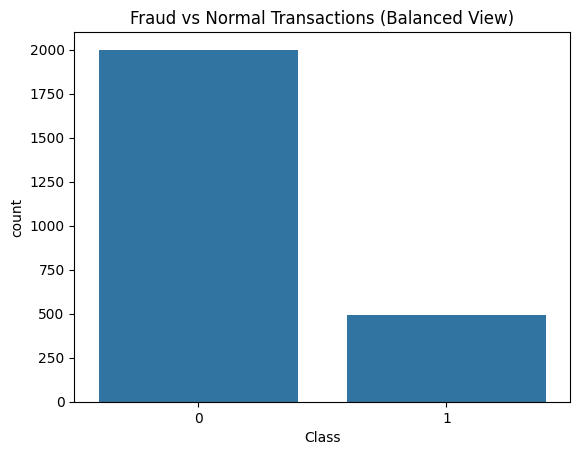

In [4]:
fraud = data[data['Class'] == 1]
normal = data[data['Class'] == 0].sample(n=5000, random_state=42)

temp_data = pd.concat([fraud, normal])

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=temp_data["Class"])
plt.title("Fraud vs Normal Transactions (Balanced View)")
plt.show()

In [5]:
X = data.drop("Class", axis=1)
y = data["Class"]

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X["Amount"] = scaler.fit_transform(X["Amount"].values.reshape(-1,1))

In [7]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
y_res.value_counts()

Class
0    284315
1    284315
Name: count, dtype: int64

In [8]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

print(y_rus.value_counts())

Class
0    492
1    492
Name: count, dtype: int64


In [9]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X, y)

print(y_ros.value_counts())

Class
0    284315
1    284315
Name: count, dtype: int64


In [10]:
X_small= X_res.sample(n=15000,random_state=42)
y_small= y_res.loc[X_small.index]

In [11]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X, y)

print("SMOTE:\n", y_sm.value_counts())

SMOTE:
 Class
0    284315
1    284315
Name: count, dtype: int64


In [12]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

print("UnderSampling:\n", y_rus.value_counts())

UnderSampling:
 Class
0    492
1    492
Name: count, dtype: int64


In [14]:
X_sm = X_sm.sample(n=20000, random_state=42)
y_sm = y_sm.loc[X_sm.index]

In [15]:
from sklearn.model_selection import train_test_split

# SMOTE 80-20
X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(
    X_sm, y_sm, test_size=0.2, random_state=42
)

# UnderSampling 80-20
X_train_rus, X_test_rus, y_train_rus, y_test_rus = train_test_split(
    X_rus, y_rus, test_size=0.2, random_state=42
)

# OverSampling 80-20
X_train_ros, X_test_ros, y_train_ros, y_test_ros = train_test_split(
    X_ros, y_ros, test_size=0.2, random_state=42
)

In [16]:
# SMOTE 70-30
X_train_sm2, X_test_sm2, y_train_sm2, y_test_sm2 = train_test_split(
    X_sm, y_sm, test_size=0.3, random_state=42
)

# UnderSampling 70-30
X_train_rus2, X_test_rus2, y_train_rus2, y_test_rus2 = train_test_split(
    X_rus, y_rus, test_size=0.3, random_state=42
)

# OverSampling 70-30
X_train_ros2, X_test_ros2, y_train_ros2, y_test_ros2 = train_test_split(
    X_ros, y_ros, test_size=0.3, random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    "Logistic": LogisticRegression(max_iter=300),
    "Decision Tree": DecisionTreeClassifier(max_depth=6),
    "Random Forest": RandomForestClassifier(n_estimators=10),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "XGBoost": XGBClassifier(n_estimators=10, max_depth=3)
}

In [18]:
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")
print("----- SMOTE 80-20 -----")

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_sm)
    print(name, "Accuracy:", accuracy_score(y_test_sm, y_pred))

----- SMOTE 80-20 -----
Logistic Accuracy: 0.9765
Decision Tree Accuracy: 0.971
Random Forest Accuracy: 0.99175
KNN Accuracy: 0.82975
XGBoost Accuracy: 0.96775


In [19]:
print("----- UnderSampling 80-20 -----")

for name, model in models.items():
    model.fit(X_train_rus, y_train_rus)
    y_pred = model.predict(X_test_rus)
    print(name, "Accuracy:", accuracy_score(y_test_rus, y_pred))

----- UnderSampling 80-20 -----
Logistic Accuracy: 0.9238578680203046
Decision Tree Accuracy: 0.8883248730964467
Random Forest Accuracy: 0.9137055837563451
KNN Accuracy: 0.6852791878172588
XGBoost Accuracy: 0.8984771573604061


In [20]:
print("----- OverSampling 80-20 -----")

for name, model in models.items():
    model.fit(X_train_ros, y_train_ros)
    y_pred = model.predict(X_test_ros)
    print(name, "Accuracy:", accuracy_score(y_test_ros, y_pred))

----- OverSampling 80-20 -----
Logistic Accuracy: 0.9495102263334682
Decision Tree Accuracy: 0.9696111707085451
Random Forest Accuracy: 0.9999560346798445
KNN Accuracy: 0.9999120693596891
XGBoost Accuracy: 0.9533176230589311


In [21]:
best_model = XGBClassifier()
best_model.fit(X_train_sm, y_train_sm)

y_pred = best_model.predict(X_test_sm)

In [22]:
print("----- SMOTE 70-30 -----")

for name, model in models.items():
    model.fit(X_train_sm2, y_train_sm2)
    y_pred = model.predict(X_test_sm2)
    print(name, "Accuracy:", accuracy_score(y_test_sm2, y_pred))

----- SMOTE 70-30 -----
Logistic Accuracy: 0.9768333333333333
Decision Tree Accuracy: 0.9691666666666666
Random Forest Accuracy: 0.989
KNN Accuracy: 0.8165
XGBoost Accuracy: 0.9688333333333333


In [23]:
print("----- UnderSampling 70-30 -----")

for name, model in models.items():
    model.fit(X_train_rus2, y_train_rus2)
    y_pred = model.predict(X_test_rus2)
    print(name, "Accuracy:", accuracy_score(y_test_rus2, y_pred))

----- UnderSampling 70-30 -----
Logistic Accuracy: 0.9324324324324325
Decision Tree Accuracy: 0.902027027027027
Random Forest Accuracy: 0.918918918918919
KNN Accuracy: 0.6554054054054054
XGBoost Accuracy: 0.9290540540540541


In [24]:
print("----- OverSampling 70-30 -----")

for name, model in models.items():
    model.fit(X_train_ros2, y_train_ros2)
    y_pred = model.predict(X_test_ros2)
    print(name, "Accuracy:", accuracy_score(y_test_ros2, y_pred))

----- OverSampling 70-30 -----
Logistic Accuracy: 0.9476285106308144
Decision Tree Accuracy: 0.969312206531488
Random Forest Accuracy: 0.999970689786563
KNN Accuracy: 0.9998534489328151
XGBoost Accuracy: 0.9561929549970983


In [25]:
results = []

# SMOTE
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_sm)
    acc = accuracy_score(y_test_sm, y_pred)
    results.append(["SMOTE", name, acc])

# UnderSampling
for name, model in models.items():
    model.fit(X_train_rus, y_train_rus)
    y_pred = model.predict(X_test_rus)
    acc = accuracy_score(y_test_rus, y_pred)
    results.append(["UnderSampling", name, acc])

# OverSampling
for name, model in models.items():
    model.fit(X_train_ros, y_train_ros)
    y_pred = model.predict(X_test_ros)
    acc = accuracy_score(y_test_ros, y_pred)
    results.append(["OverSampling", name, acc])

In [26]:
import pandas as pd

df_results = pd.DataFrame(results, columns=["Method", "Model", "Accuracy"])
df_results

,Method,Model,Accuracy
0,SMOTE,Logistic,0.976500
1,SMOTE,Decision Tree,0.970000
2,SMOTE,Random Forest,0.991750
3,SMOTE,KNN,0.829750
4,SMOTE,XGBoost,0.967750
5,UnderSampling,Logistic,0.923858
6,UnderSampling,Decision Tree,0.888325
7,UnderSampling,Random Forest,0.923858
8,UnderSampling,KNN,0.685279
9,UnderSampling,XGBoost,0.898477


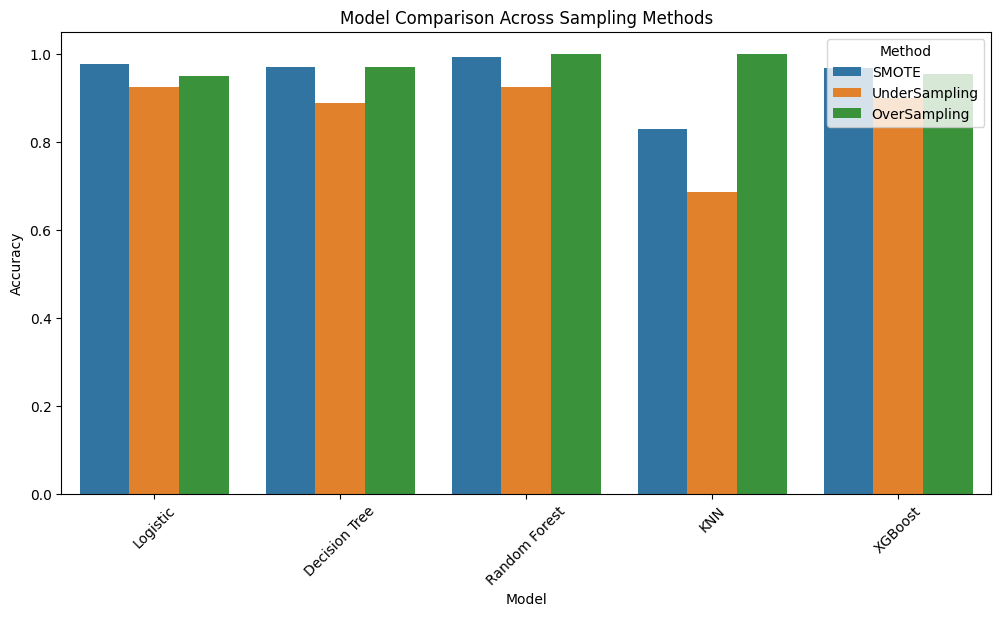

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(x="Model", y="Accuracy", hue="Method", data=df_results)

plt.title("Model Comparison Across Sampling Methods")
plt.xticks(rotation=45)
plt.show()

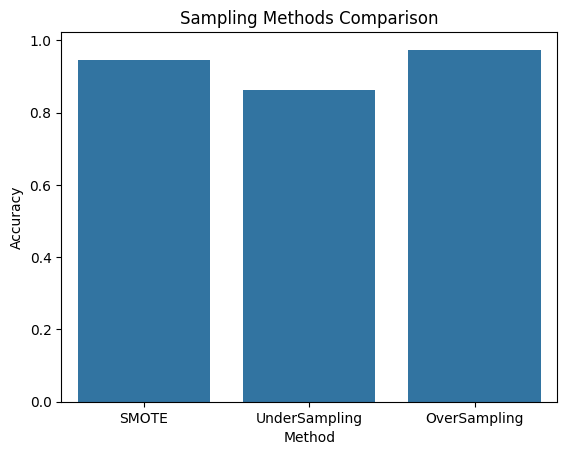

In [28]:
sns.barplot(x="Method", y="Accuracy", data=df_results, errorbar=None)

plt.title("Sampling Methods Comparison")
plt.show()

In [29]:
best_model = XGBClassifier()
best_model.fit(X_train_sm, y_train_sm)

y_pred = best_model.predict(X_test_sm)

In [30]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np

kf = KFold(n_splits=4, shuffle=True, random_state=42)

model = XGBClassifier()

scores = []

for train_index, test_index in kf.split(X_sm):
    X_train, X_test = X_sm.iloc[train_index], X_sm.iloc[test_index]
    y_train, y_test = y_sm.iloc[train_index], y_sm.iloc[test_index]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)

print("Fold Accuracies:", scores)
print("Average Accuracy:", np.mean(scores))

Fold Accuracies: [0.995, 0.9972, 0.9974, 0.9946]
Average Accuracy: 0.99605


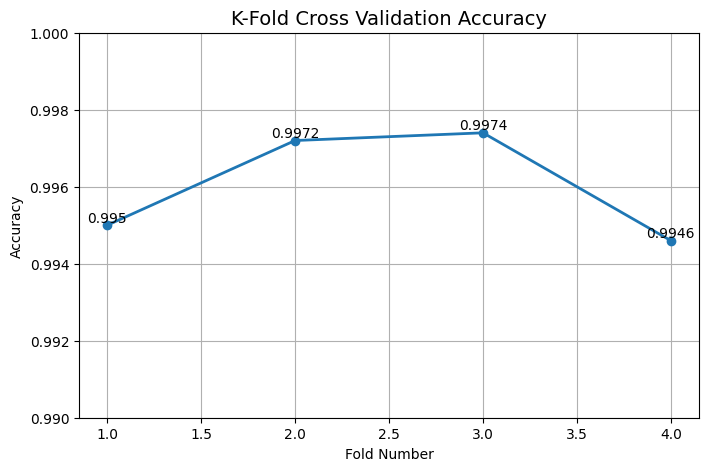

In [44]:
import matplotlib.pyplot as plt

folds = [1, 2, 3, 4]
scores = [0.995, 0.9972, 0.9974, 0.9946]

plt.figure(figsize=(8,5))

plt.plot(folds, scores, marker='o', linestyle='-', linewidth=2)

plt.title("K-Fold Cross Validation Accuracy", fontsize=14)
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")

plt.ylim(0.99, 1.0)

for i, score in enumerate(scores):
    plt.text(folds[i], score, round(score,4), ha='center', va='bottom')

plt.grid(True)
plt.show()

In [31]:
X_sm = X_sm.sample(n=15000, random_state=42)
y_sm = y_sm.loc[X_sm.index]

In [32]:
from sklearn.model_selection import train_test_split

X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(
    X_sm, y_sm, test_size=0.2, random_state=42
)

In [33]:
best_model = XGBClassifier(n_estimators=20)
best_model.fit(X_train_sm, y_train_sm)

y_pred = best_model.predict(X_test_sm)

In [34]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test_sm, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test_sm, y_pred))

Confusion Matrix:
 [[1474    6]
 [  24 1496]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1480
           1       1.00      0.98      0.99      1520

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test_sm, y_pred))
print("Precision:", precision_score(y_test_sm, y_pred))
print("Recall:", recall_score(y_test_sm, y_pred))
print("F1 Score:", f1_score(y_test_sm, y_pred))

Accuracy: 0.99
Precision: 0.996005326231691
Recall: 0.9842105263157894
F1 Score: 0.9900727994705493


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_results = []

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_sm)

    acc = accuracy_score(y_test_sm, y_pred)
    prec = precision_score(y_test_sm, y_pred)
    rec = recall_score(y_test_sm, y_pred)
    f1 = f1_score(y_test_sm, y_pred)

    metrics_results.append([name, acc, prec, rec, f1])

In [37]:
import pandas as pd

df_metrics = pd.DataFrame(metrics_results, 
                         columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

df_metrics

,Model,Accuracy,Precision,Recall,F1
0,Logistic,0.979000,0.991234,0.967105,0.979021
1,Decision Tree,0.974667,0.985868,0.963816,0.974717
2,Random Forest,0.988000,0.997319,0.978947,0.988048
3,KNN,0.801667,0.808128,0.798026,0.803045
4,XGBoost,0.970667,0.990411,0.951316,0.970470


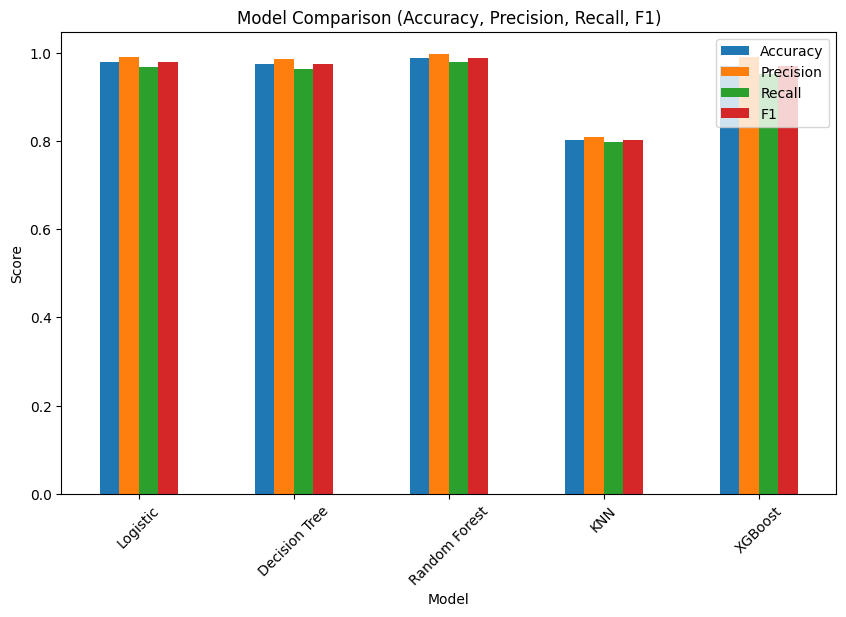

In [38]:
import matplotlib.pyplot as plt

df_metrics.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Comparison (Accuracy, Precision, Recall, F1)")
plt.xticks(rotation=45)
plt.ylabel("Score")
plt.show()

In [39]:
probs = best_model.predict_proba(X_test_sm)

fraud_prob = probs[:,1]

In [40]:
for i in range(10):
    score = fraud_prob[i] * 100

    if score < 30:
        status = "SAFE"
    elif score < 70:
        status = "SUSPICIOUS"
    else:
        status = "FRAUD"

    print("Transaction", i+1,
          "| Risk:", round(score,2), "%",
          "| Status:", status)

Transaction 1 | Risk: 99.83 % | Status: FRAUD
Transaction 2 | Risk: 0.29 % | Status: SAFE
Transaction 3 | Risk: 99.88 % | Status: FRAUD
Transaction 4 | Risk: 99.88 % | Status: FRAUD
Transaction 5 | Risk: 0.91 % | Status: SAFE
Transaction 6 | Risk: 0.51 % | Status: SAFE
Transaction 7 | Risk: 0.27 % | Status: SAFE
Transaction 8 | Risk: 99.11 % | Status: FRAUD
Transaction 9 | Risk: 99.88 % | Status: FRAUD
Transaction 10 | Risk: 0.16 % | Status: SAFE


In [41]:
for i in range(10):
    score = fraud_prob[i] * 100
    
    if score > 80:
        reason = "Highly suspicious transaction pattern detected"
    elif score > 50:
        reason = "Moderate anomaly in transaction features"
    else:
        reason = "Normal transaction behavior"
    
    print("Transaction", i+1)
    print("Risk:", round(score,2), "%")
    print("Explanation:", reason)
    print("-----------")

Transaction 1
Risk: 99.83 %
Explanation: Highly suspicious transaction pattern detected
-----------
Transaction 2
Risk: 0.29 %
Explanation: Normal transaction behavior
-----------
Transaction 3
Risk: 99.88 %
Explanation: Highly suspicious transaction pattern detected
-----------
Transaction 4
Risk: 99.88 %
Explanation: Highly suspicious transaction pattern detected
-----------
Transaction 5
Risk: 0.91 %
Explanation: Normal transaction behavior
-----------
Transaction 6
Risk: 0.51 %
Explanation: Normal transaction behavior
-----------
Transaction 7
Risk: 0.27 %
Explanation: Normal transaction behavior
-----------
Transaction 8
Risk: 99.11 %
Explanation: Highly suspicious transaction pattern detected
-----------
Transaction 9
Risk: 99.88 %
Explanation: Highly suspicious transaction pattern detected
-----------
Transaction 10
Risk: 0.16 %
Explanation: Normal transaction behavior
-----------


In [42]:


importance = best_model.feature_importances_

feat_imp = pd.Series(importance)
feat_imp.nlargest(5)

14    0.632780
12    0.048711
17    0.048101
4     0.028242
3     0.017365
dtype: float32

In [43]:
for i in range(10):
    score = fraud_prob[i] * 100
    
    if score > 80:
        alert = "FRAUD ALERT! Block Transaction"
    elif score > 50:
        alert = "Suspicious Transaction - Review Needed"
    else:
        alert = "Safe Transaction"
    
    print("Transaction", i+1)
    print("Risk:", round(score,2), "%")
    print("Alert:", alert)
    print("-----------")

Transaction 1
Risk: 99.83 %
Alert: FRAUD ALERT! Block Transaction
-----------
Transaction 2
Risk: 0.29 %
Alert: Safe Transaction
-----------
Transaction 3
Risk: 99.88 %
Alert: FRAUD ALERT! Block Transaction
-----------
Transaction 4
Risk: 99.88 %
Alert: FRAUD ALERT! Block Transaction
-----------
Transaction 5
Risk: 0.91 %
Alert: Safe Transaction
-----------
Transaction 6
Risk: 0.51 %
Alert: Safe Transaction
-----------
Transaction 7
Risk: 0.27 %
Alert: Safe Transaction
-----------
Transaction 8
Risk: 99.11 %
Alert: FRAUD ALERT! Block Transaction
-----------
Transaction 9
Risk: 99.88 %
Alert: FRAUD ALERT! Block Transaction
-----------
Transaction 10
Risk: 0.16 %
Alert: Safe Transaction
-----------
